In [1]:
#=========================================================================
# 1. 멀티스레딩을 이용한 로그 파일 병렬 읽기
# 2. 단일 쓰레드 vs 멀티 쓰레드 처리시간을 비교
#=========================================================================

In [15]:
import os
import time
import concurrent.futures
import matplotlib.pyplot as plt

In [16]:
LOG_DIR = './data/log_files'

In [17]:
os.makedirs(LOG_DIR, exist_ok=True)

In [18]:
for i in range(500):
    file_path = os.path.join(LOG_DIR, f'log_{i}.txt')                 # 파일 경로에 log_files/log_i.txt 형태로 파일 생성
    if not os.path.exists(file_path):                                 # 해당 파일이 존재하지 않을때만 새로 생성 
        with open(file_path, 'w', encoding='utf-8') as f:             # 쓰기 모드로만 파일을 연다
            f.write(('Sensor Value : ' + str(i) + '\n') * 3000)       # 센서 값 텍스트를 1000줄 기록

In [19]:
files = [os.path.join(LOG_DIR,f) for f in os.listdir(LOG_DIR)]   # 로드 폴더 내의 파일 경로를 리스트로 가져옴

In [20]:
# 파일 읽어오기
def read_file(path: str) -> str:                            
    with open(path, 'r', encoding='utf-8') as f:   # 읽기 모드로 파일 가져온다
        content = f.read()                         # 파일 전체 내용을 읽어온다 
    return content                                 # 읽은 내용을 호출한 쪽에 반환

In [21]:
## 단일 쓰레드
start_single = time.time()                      # 단일 쓰레드 방식 시작 시간 측정
for path_ in files:                              # 파일을 순차적으로 읽음
    _ = read_file(path_)                        # 내용을 읽어오고 
end_single = time.time()                       # 단일 쓰레드 방식 종료 시간 기록
elapsed_single = end_single - start_single      # 걸린 시간(초) 계산

print(f'단일 쓰레드 처리시간 : {elapsed_single:.4f}초')

단일 쓰레드 처리시간 : 5.0002초


In [22]:
## 멀티 쓰레드
start_multi = time.time()                         # 시작 시간
# threadpoolexecutor를 사용해서 쓰레드 풀을 생성하고, 파일 리스트를 병렬 읽어옴
with concurrent.futures.ThreadPoolExecutor() as executor:  
    list(executor.map(read_file, files))          # executor.map으로 read_file 함수를 file 목록에 병렬로 적용
end_multi = time.time()                           # 종료시간
elapsed_multi = end_multi - start_multi      # 걸린 시간(초) 계산

print(f'멀티 쓰레드 처리시간 : {elapsed_multi:.4f}초')

멀티 쓰레드 처리시간 : 0.1384초


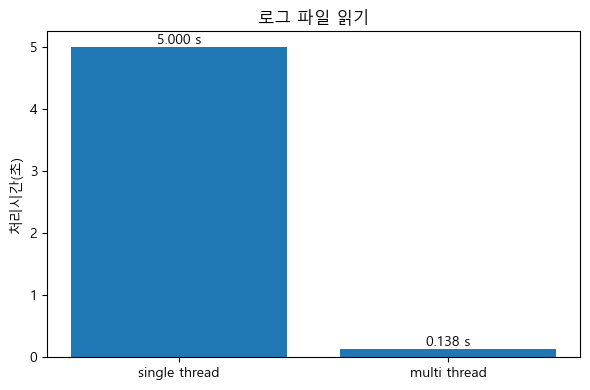

In [25]:
# 그래프 한글 폰트 설정
from matplotlib import font_manager, rc
plt.rcParams['font.family'] = 'Malgun Gothic'          # 한글 폰트 지정
plt.rcParams['axes.unicode_minus'] = False             # 마이너스 부호 깨짐 방지

## 성능 비교 시각화
labels = ['single thread','multi thread']
times = [elapsed_single, elapsed_multi]

plt.figure(figsize=(6,4))
plt.bar(labels, times)
plt.ylabel('처리시간(초)')
plt.title('로그 파일 읽기')


# 각 막대 위에 시간 값 표기
for i, v in enumerate(times):
    plt.text(i, v, f'{v:.3f} s',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [26]:
#=========================================================================
# AsyncIO를 이용한 API 호출 
#=========================================================================
# 동기 방식 vs 비동기 방식 처리시간을 비교

In [27]:
import os
import time
import asyncio
import matplotlib.pyplot as plt
import nest_asyncio

nest_asyncio.apply()

In [28]:
async def async_machine_request(machine_id : int, delay: float = 0.5) -> str:
    await asyncio.sleep(delay)                   # delay 시간 동안 비동기적으로 대기
    return f'Machine {machine_id} ok'            # 설비 상태가 정상이라고 가정하고 문자열 반환       

In [29]:
## 동기 방식 처리
def sync_machine_request(machine_id: int, delay: float=0.5) -> str:
    time.sleep(delay)
    return f'Machine {machine_id} ok'

In [36]:
## 비동기 방식 처리
async def run_async_requests(num_machines: int=10, delay:float=0.5):
    tasks = []                                               # 비동기 작업들을 저장할 리스트
    for m_id in range(num_machines):                         # 0부터 num_machine-1까지 설비 id를 반복
        tasks.append(async_machine_request(m_id, delay))     # async_machine_request 루틴을 해서 tasks에 값을 추가

    results = await asyncio.gather(*tasks)                   # 동시에 실행하고 결과를 리스트로 모아주는 역할
    return results                                           # 모든 설비의 응답 결과 리스트 반환

def run_sync_requests(num_machines: int=10, delay:float=0.5):   
    results = []
    for m_id in range(num_machines):
        res = sync_machine_request(m_id, delay)
        results.append(res)
    return results
    

[동기 방식] 전체 처리 시간: 5.0066 초
[동기 방식] 응답 예시: ['Machine 0 ok', 'Machine 1 ok', 'Machine 2 ok'] ...
[비동기 방식] 전체 처리 시간: 0.5132 초
[비동기 방식] 응답 예시: ['Machine 0 ok', 'Machine 1 ok', 'Machine 2 ok'] ...


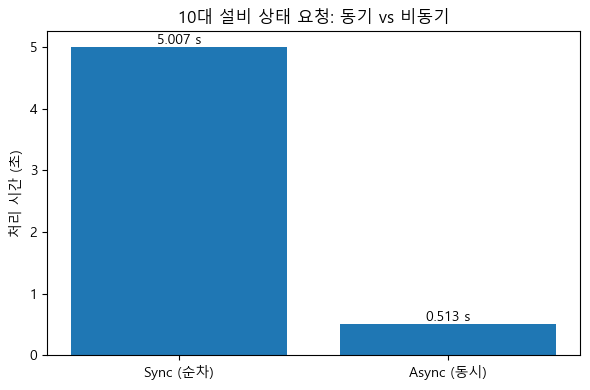

In [37]:
def main():
   
    num_machines = 10                                # 설비 개수(예: 10대 설비)
    delay_per_req = 0.5                              # 각 설비 요청당 0.5초 지연을 가정

    # ------------------ 동기(순차) 방식 처리 시간 측정 ------------------
    start_sync = time.time()                         # 동기 처리 시작 시간 기록
    sync_results = run_sync_requests(num_machines, delay_per_req)  # 동기 방식 호출
    end_sync = time.time()                           # 동기 처리 종료 시간 기록
    elapsed_sync = end_sync - start_sync             # 동기 처리에 걸린 총 시간 계산

    print(f"[동기 방식] 전체 처리 시간: {elapsed_sync:.4f} 초")
    print(f"[동기 방식] 응답 예시: {sync_results[:3]} ...")  # 앞 3개 결과만 예시 출력

    # ----------------- 비동기(동시) 방식 처리 시간 측정 ------------------
    start_async = time.time()                        # 비동기 처리 시작 시간 기록
    async_results = asyncio.run(
        run_async_requests(num_machines, delay_per_req)
    )                                                # 비동기 방식 호출 실행
    end_async = time.time()                          # 비동기 처리 종료 시간 기록
    elapsed_async = end_async - start_async          # 비동기 처리에 걸린 총 시간 계산

    print(f"[비동기 방식] 전체 처리 시간: {elapsed_async:.4f} 초")
    print(f"[비동기 방식] 응답 예시: {async_results[:3]} ...")  # 앞 3개 결과 예시 출력

    # ---------------------- 처리 시간 비교 시각화 -----------------------
    labels = ['Sync (순차)', 'Async (동시)']         # 막대그래프 레이블
    times = [elapsed_sync, elapsed_async]            # 동기/비동기 처리시간 리스트

    plt.figure(figsize=(6, 4))                       # 그래프 크기 설정
    plt.bar(labels, times)                           # 막대그래프 그리기
    plt.ylabel("처리 시간 (초)")                     # y축 라벨 설정
    plt.title(f"{num_machines}대 설비 상태 요청: 동기 vs 비동기")  # 그래프 제목 설정

    # 각 막대 위에 숫자로 처리시간 표시
    for i, v in enumerate(times):                    # 인덱스와 값 동시에 순회
        plt.text(i, v, f"{v:.3f} s",                 # (x=i, y=v 위치에 텍스트 출력)
                 ha="center", va="bottom")

    plt.tight_layout()                               # 레이아웃 자동 조정
    plt.show()                                       # 그래프 표시


if __name__ == "__main__":
    main()                  
